## ১. 📌 Introduction to RNN Propagation

### RNN কীভাবে শেখে?

RNN (Recurrent Neural Network) sequential data প্রসেস করার সময় দুটি প্রধান ধাপ অতিক্রম করে:

| ধাপ | নাম | কী হয় |
|:---:|:---|:---|
| **১** | **Forward Propagation** | ইনপুট থেকে আউটপুট পর্যন্ত ডাটা প্রবাহিত হয়, hidden state তৈরি হয় |
| **২** | **Backward Propagation (BPTT)** | আউটপুট থেকে শুরু করে পেছনে গিয়ে gradient calculate করা হয় এবং weights আপডেট হয় |

### 🔑 Key Components (গুরুত্বপূর্ণ উপাদান)

```
Wᵢ = Input-to-hidden weights   (ইনপুট থেকে হিডেনে যাওয়ার ওয়েট)
Wₕ = Hidden-to-hidden weights  (হিডেন থেকে হিডেনে যাওয়ার ওয়েট)
Wₒ = Hidden-to-output weights  (হিডেন থেকে আউটপুটে যাওয়ার ওয়েট)
b  = Biases                     (বায়াস)
```

### 🔄 Training Flow

```
Input → Forward Propagation → Output → Calculate Loss → Backward Propagation (BPTT) → Update Weights
  
```

---

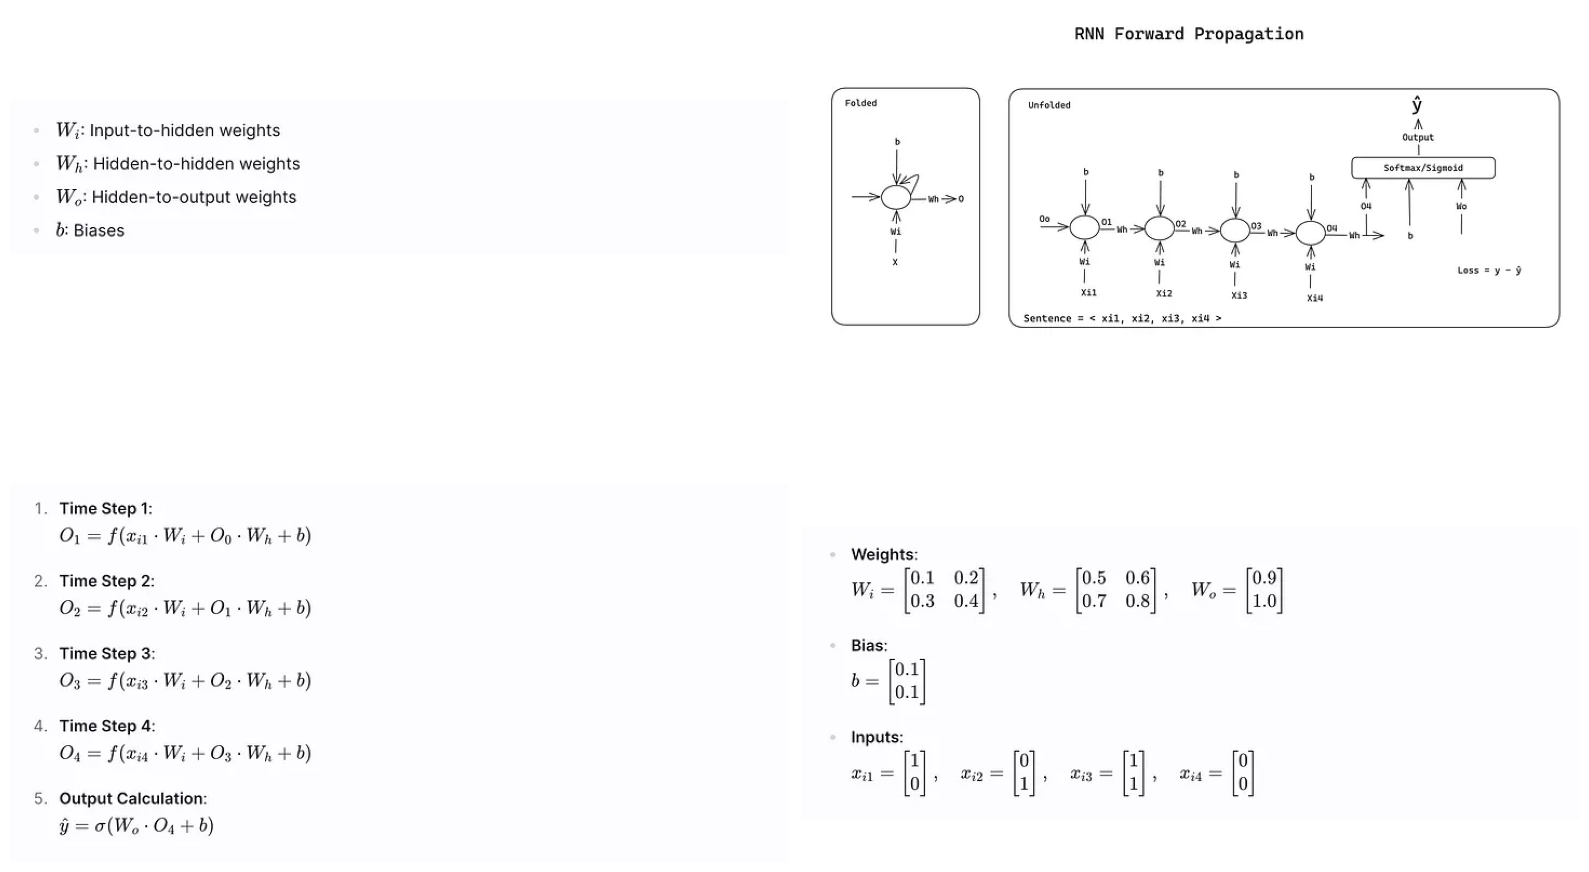

In [ ]:
from matplotlib import pyplot as plt
from PIL import Image

# Load images
main_img = Image.open('/content/forward1.png')
right_img = Image.open('/content/forward2.png')
left_bottom_img = Image.open('/content/forward3.png')
right_bottom_img = Image.open('/content/forward4.png')

# Bigger figure size
fig = plt.figure(figsize=(16,12))

# Main image
plt.subplot(2,2,1)
plt.imshow(main_img)
plt.axis('off')

# Right image
plt.subplot(2,2,2)
plt.imshow(right_img)
plt.axis('off')

# Left bottom image
plt.subplot(2,2,3)
plt.imshow(left_bottom_img)
plt.axis('off')

# Right bottom image
plt.subplot(2,2,4)
plt.imshow(right_bottom_img)
plt.axis('off')

# Space adjustment
plt.tight_layout()

plt.show()



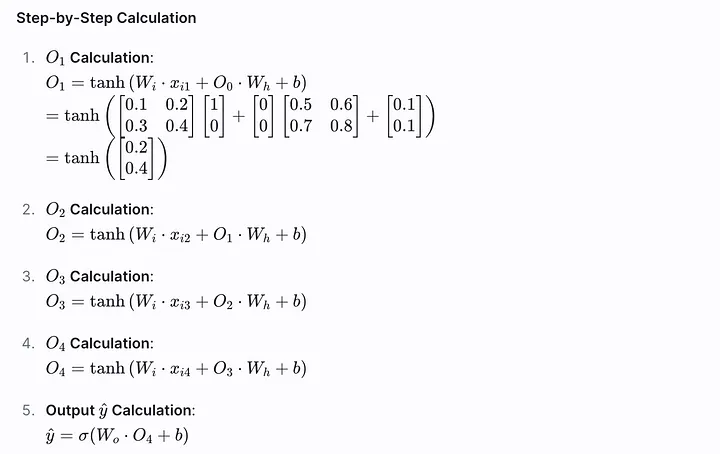

In [ ]:
from IPython.display import Image, display
display(Image('/content/forward5.png'))

## ২. ➡️ Forward Propagation — বিস্তারিত ব্যাখ্যা

### Forward Propagation কী?

Forward Propagation হল সেই প্রক্রিয়া যেখানে ইনপুট ডাটা নেটওয়ার্কের মধ্য দিয়ে প্রবাহিত হয় এবং প্রতিটি সময় ধাপে hidden state তৈরি করে। RNN তার hidden state ব্যবহার করে **temporal dependencies** (সময়ের উপর নির্ভরশীল সম্পর্ক) ধরে রাখে।

### 🖼️ Visual Representation

```
Time Step:   t=0      t=1      t=2      t=3      t=4
           ┌─────┐  ┌─────┐  ┌─────┐  ┌─────┐  ┌─────┐
Input x:   │     │  │ x₁  │  │ x₂  │  │ x₃  │  │ x₄  │
           └─────┘  └──┬──┘  └──┬──┘  └──┬──┘  └──┬──┘
                        │        │        │        │
                        ▼        ▼        ▼        ▼
           ┌─────┐  ┌─────┐  ┌─────┐  ┌─────┐  ┌─────┐
Hidden h:  │ h₀  │─▶│ h₁  │─▶│ h₂  │─▶│ h₃  │─▶│ h₄  │
           └─────┘  └──┬──┘  └──┬──┘  └──┬──┘  └──┬──┘
                        │        │        │        │
                        ▼        ▼        ▼        ▼
           ┌─────┐  ┌─────┐  ┌─────┐  ┌─────┐  ┌─────┐
Output ŷ:  │     │  │ ŷ₁  │  │ ŷ₂  │  │ ŷ₃  │  │ ŷ₄  │
           └─────┘  └─────┘  └─────┘  └─────┘  └─────┘

h₀ = Initial hidden state (usually zeros)
```

### 📐 Equations for Forward Propagation (সমীকরণ)

```python
# প্রতিটি টাইম স্টেপের জন্য সমীকরণ

# Time Step 1:
h₁ = tanh(x₁ · Wᵢ + h₀ · Wₕ + b)

# Time Step 2:
h₂ = tanh(x₂ · Wᵢ + h₁ · Wₕ + b)

# Time Step 3:
h₃ = tanh(x₃ · Wᵢ + h₂ · Wₕ + b)

# Time Step 4:
h₄ = tanh(x₄ · Wᵢ + h₃ · Wₕ + b)

# General Form:
hₜ = tanh(xₜ · Wᵢ + hₜ₋₁ · Wₕ + b)

# Final Output Calculation:
ŷ = σ(Wₒ · hₜ + b)
```

> ⚠️ **গুরুত্বপূর্ণ:** Wᵢ, Wₕ, Wₒ ওয়েটগুলি সব টাইম স্টেপে **শেয়ার (একই)** হয়! শুধু hidden state h₁, h₂, h₃, h₄ ভিন্ন হয়।

---

## ৩. 🔢 Forward Propagation — বাস্তব উদাহরণ (Numerical Example)

ধরা যাক আমাদের কাছে নিচের ম্যাট্রিক্স এবং ভ্যালুগুলো আছে:

### Given Values

```
Weights (ওয়েট ম্যাট্রিক্স):
  Wᵢ = [[0.5, 0.6],   (input-to-hidden weight)
         [0.7, 0.8]]

  Wₕ = [[0.9, 1.0],   (hidden-to-hidden weight)
         [1.1, 1.2]]

  Wₒ = [0.4, 0.5]     (hidden-to-output weight)

Bias:
  b  = [0.3, 0.4]

Input Sequence:
  x₁ = [0.2, 0.3]
  x₂ = [0.4, 0.5]
  x₃ = [0.6, 0.7]
  x₄ = [0.8, 0.9]

Initial Hidden State:
  h₀ = [0.0, 0.0]
```

---

### 📝 Step-by-Step Calculation

#### ✅ Step 1: Calculate h₁

```
h₁ = tanh(Wᵢ · x₁ + Wₕ · h₀ + b)

Step 1a: Wᵢ · x₁ = [0.5×0.2 + 0.6×0.3,  0.7×0.2 + 0.8×0.3]
                   = [0.10 + 0.18,          0.14 + 0.24]
                   = [0.28, 0.38]

Step 1b: Wₕ · h₀ = [0.9×0.0 + 1.0×0.0,  1.1×0.0 + 1.2×0.0]
                  = [0.0, 0.0]

Step 1c: Add bias: [0.28 + 0.3,  0.38 + 0.4] = [0.58, 0.78]

Step 1d: Apply tanh:
         h₁ = [tanh(0.58), tanh(0.78)] = [0.522, 0.652]
```

#### ✅ Step 2: Calculate h₂

```
h₂ = tanh(Wᵢ · x₂ + Wₕ · h₁ + b)

Wᵢ · x₂ = [0.5×0.4 + 0.6×0.5,  0.7×0.4 + 0.8×0.5]
          = [0.20+0.30,  0.28+0.40]
          = [0.50, 0.68]

Wₕ · h₁ = [0.9×0.522 + 1.0×0.652,  1.1×0.522 + 1.2×0.652]
          = [0.470 + 0.652,  0.574 + 0.782]
          = [1.122, 1.356]

Sum + bias: [0.50+1.122+0.3,  0.68+1.356+0.4] = [1.922, 2.436]

h₂ = [tanh(1.922), tanh(2.436)] = [0.958, 0.984]
```

#### ✅ Step 3: Calculate h₃

```
h₃ = tanh(Wᵢ · x₃ + Wₕ · h₂ + b)

Wᵢ · x₃ = [0.5×0.6 + 0.6×0.7,  0.7×0.6 + 0.8×0.7]
          = [0.30+0.42,  0.42+0.56]
          = [0.72, 0.98]

Wₕ · h₂ = [0.9×0.958 + 1.0×0.984,  1.1×0.958 + 1.2×0.984]
          = [0.862 + 0.984,  1.054 + 1.181]
          = [1.846, 2.235]

Sum + bias: [0.72+1.846+0.3,  0.98+2.235+0.4] = [2.866, 3.615]

h₃ = [tanh(2.866), tanh(3.615)] = [0.994, 0.999]
```

#### ✅ Step 4: Calculate h₄

```
h₄ = tanh(Wᵢ · x₄ + Wₕ · h₃ + b)

Wᵢ · x₄ = [0.5×0.8 + 0.6×0.9,  0.7×0.8 + 0.8×0.9]
          = [0.40+0.54,  0.56+0.72]
          = [0.94, 1.28]

Wₕ · h₃ = [0.9×0.994 + 1.0×0.999,  1.1×0.994 + 1.2×0.999]
          = [0.895 + 0.999,  1.093 + 1.199]
          = [1.894, 2.292]

Sum + bias: [0.94+1.894+0.3,  1.28+2.292+0.4] = [3.134, 3.972]

h₄ = [tanh(3.134), tanh(3.972)] = [0.997, 0.999]
```

#### ✅ Step 5: Calculate Final Output ŷ

```
ŷ = σ(Wₒ · h₄ + b)

Wₒ · h₄ = [0.4×0.997 + 0.5×0.999]
          = [0.399 + 0.500]
          = 0.899

ŷ = σ(0.899) = 1 / (1 + e⁻⁰·⁸⁹⁹)
              = 1 / (1 + 0.407)
              = 0.711
```

> 💡 **Interpretation:** যদি এটি একটি binary classification সমস্যা হয়, তাহলে ŷ = 0.711 মানে model **71.1% confidence** বলছে class 1 হবে।

---

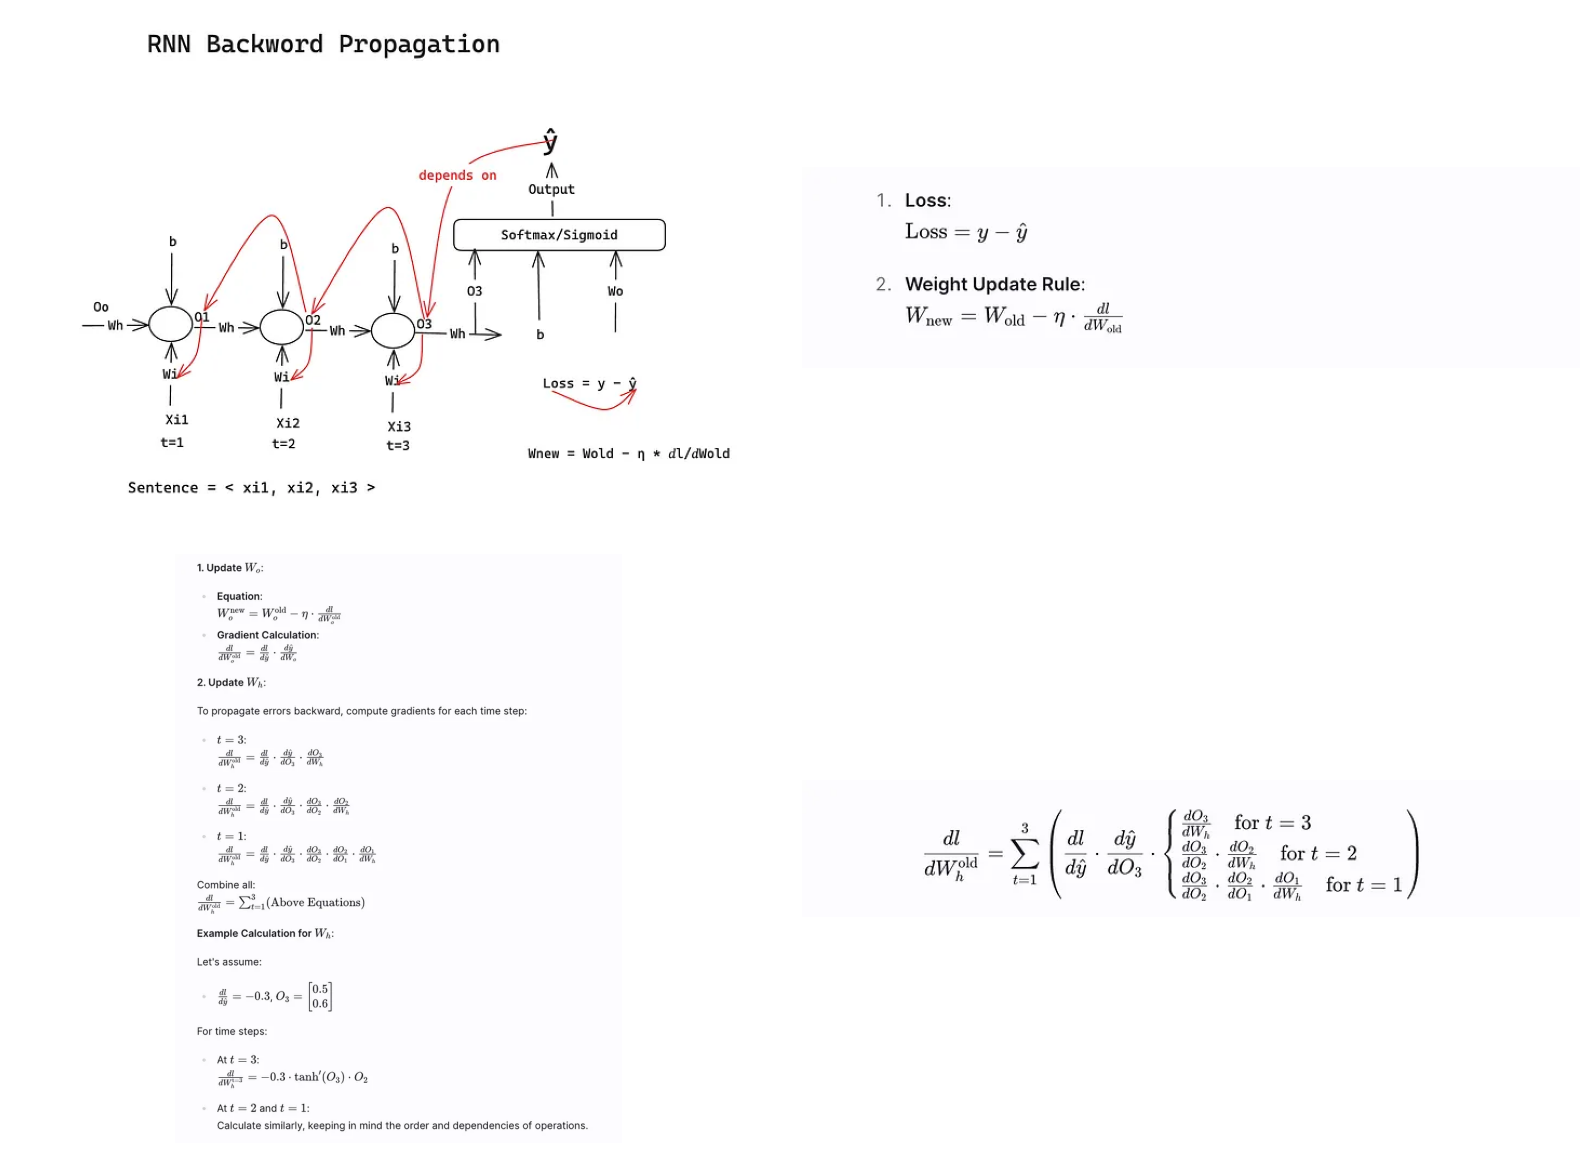

In [ ]:
from matplotlib import pyplot as plt
from PIL import Image

# Load images
main_img = Image.open('/content/backward1.png')
right_img = Image.open('/content/backward2.png')
left_bottom_img = Image.open('/content/backward3.png')
right_bottom_img = Image.open('/content/backward4.png')

# Bigger figure size
fig = plt.figure(figsize=(16,12))

# Main image
plt.subplot(2,2,1)
plt.imshow(main_img)
plt.axis('off')

# Right image
plt.subplot(2,2,2)
plt.imshow(right_img)
plt.axis('off')

# Left bottom image
plt.subplot(2,2,3)
plt.imshow(left_bottom_img)
plt.axis('off')

# Right bottom image
plt.subplot(2,2,4)
plt.imshow(right_bottom_img)
plt.axis('off')

# Space adjustment
plt.tight_layout()

plt.show()



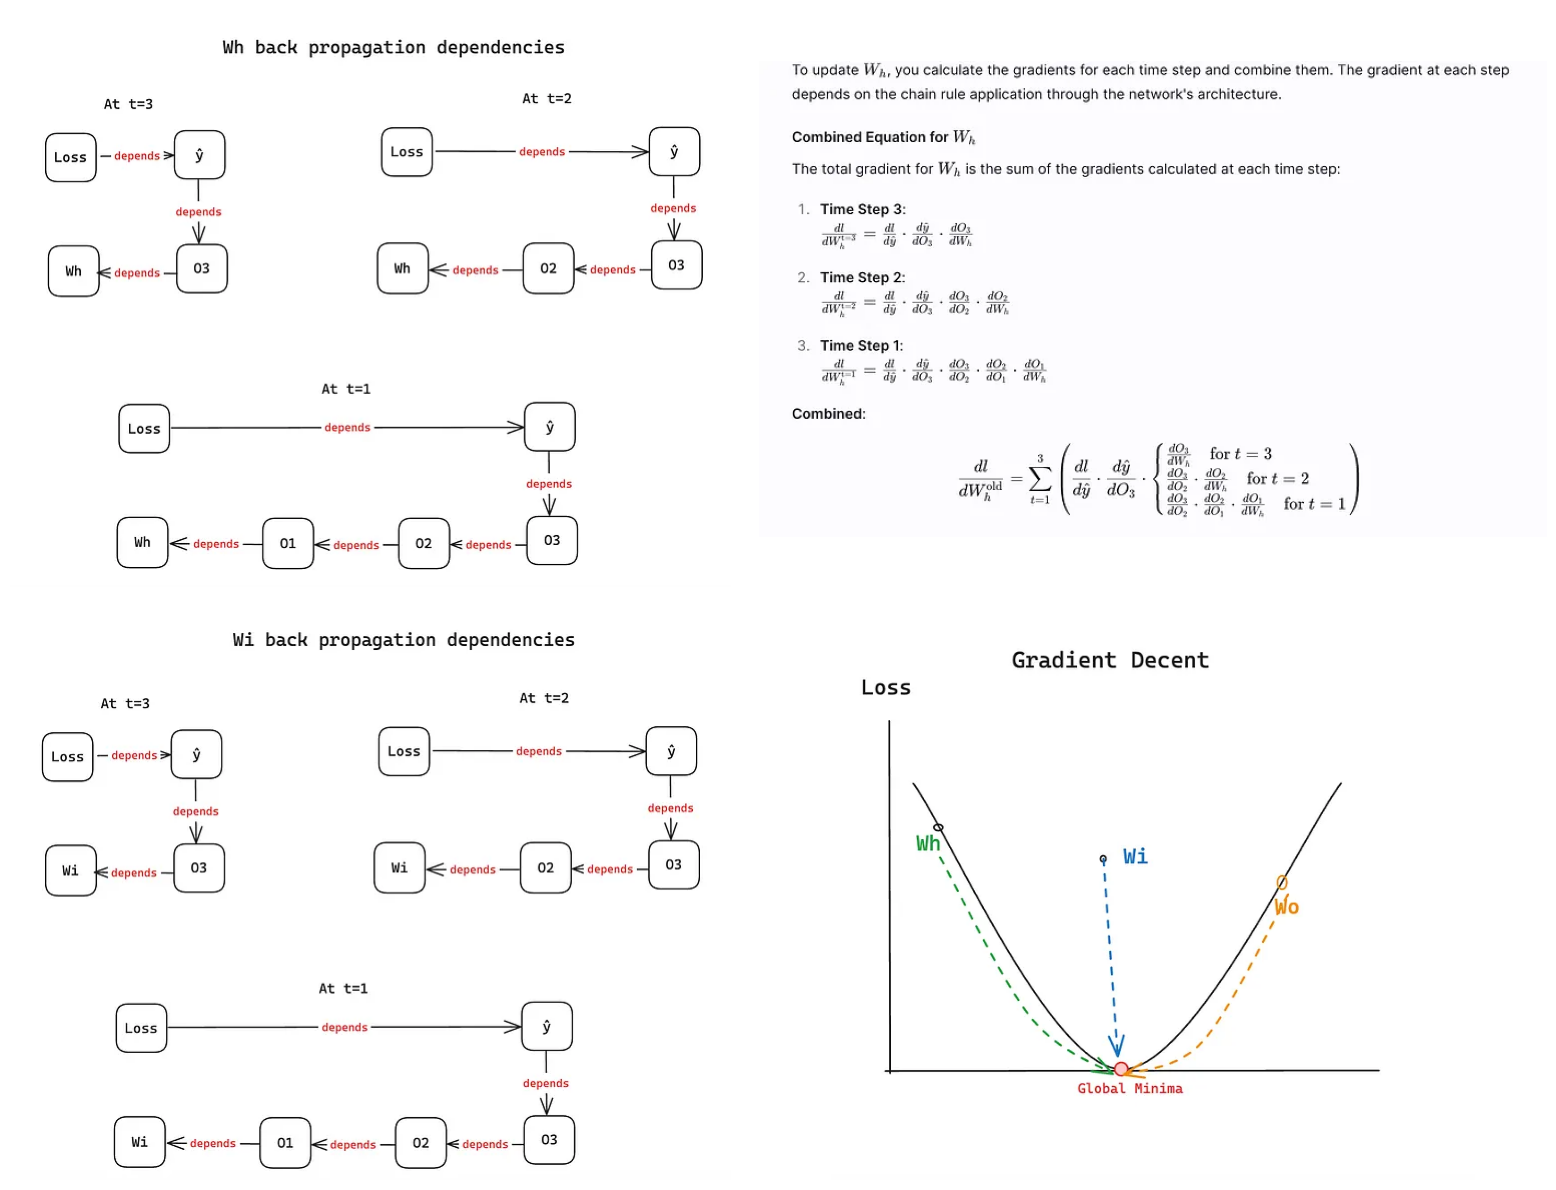

In [ ]:
from matplotlib import pyplot as plt
from PIL import Image

# Load images
main_img = Image.open('/content/backward5.png')
right_img = Image.open('/content/backward6.png')
left_bottom_img = Image.open('/content/backward7.png')
right_bottom_img = Image.open('/content/backward8.png')

# Bigger figure size
fig = plt.figure(figsize=(16,12))

# Main image
plt.subplot(2,2,1)
plt.imshow(main_img)
plt.axis('off')

# Right image
plt.subplot(2,2,2)
plt.imshow(right_img)
plt.axis('off')

# Left bottom image
plt.subplot(2,2,3)
plt.imshow(left_bottom_img)
plt.axis('off')

# Right bottom image
plt.subplot(2,2,4)
plt.imshow(right_bottom_img)
plt.axis('off')

# Space adjustment
plt.tight_layout()

plt.show()



## ৪. 📉 Loss Function — কিভাবে Error বের করে

Forward propagation শেষে আমরা predicted output ŷ পেলাম। এখন আমাদের জানতে হবে ŷ কতটুকু সঠিক?

```
Loss = (y - ŷ)²                               [Mean Squared Error — regression এর জন্য]
বা
Loss = -y·log(ŷ) - (1-y)·log(1-ŷ)            [Binary Cross Entropy — classification এর জন্য]
```

### উদাহরণ: যদি actual output y = 1 এবং ŷ = 0.711

```
MSE Loss = (1 - 0.711)²
         = (0.289)²
         = 0.0835
```

> এই loss-ই বলে আমাদের model কতটা ভুল করছে। **লক্ষ্য হল এই loss কমানো।**

---

## ৫. ⬅️ Backward Propagation Through Time (BPTT)

### BPTT কী?

**Backward Propagation Through Time (BPTT)** হল RNN-এর জন্য বিশেষ backpropagation পদ্ধতি। সাধারণ ANN-এর মতো নয়, RNN-এ gradient কে **সময়ের পেছনে** propagate করতে হয়।

```
Forward:  h₀ → h₁ → h₂ → h₃ → h₄ → ŷ → Loss
Backward: Loss → ŷ → h₄ → h₃ → h₂ → h₁ → h₀
```

> যেহেতু gradient সময়ের পেছনে (t=4 থেকে t=0) যাচ্ছে, তাই একে **"Through Time"** বলা হয়।

### 📐 Gradient Calculation Steps

```python
# Step 1: Output layer gradient
dL/dŷ = -(y/ŷ) + (1-y)/(1-ŷ)      # Binary Cross Entropy এর derivative

# Step 2: Output weight gradient
dL/dWₒ = dL/dŷ · dŷ/d(Wₒ·h₄) · h₄

# Step 3: Hidden state gradient at last time step
dL/dh₄ = dL/dŷ · dŷ/d(Wₒ·h₄) · Wₒ

# Step 4: Backpropagate through time (Chain Rule)
dL/dh₃ = dL/dh₄ · dh₄/dh₃
dL/dh₂ = dL/dh₃ · dh₃/dh₂
dL/dh₁ = dL/dh₂ · dh₂/dh₁
```

---

## ৬. 🔢 BPTT — বাস্তব উদাহরণ (Numerical Example)

### Given Values Recap

```
y (actual)    = 1.0
ŷ (predicted) = 0.711

Wₒ = [0.4, 0.5]
h₄ = [0.997, 0.999]
Wₕ = [[0.9, 1.0], [1.1, 1.2]]
Wᵢ = [[0.5, 0.6], [0.7, 0.8]]
```

#### ✅ Step 1: Calculate dL/dŷ (Loss gradient)

```
Binary Cross Entropy Loss এর derivative:

dL/dŷ = -y/ŷ + (1-y)/(1-ŷ)
      = -1/0.711 + 0/(1-0.711)
      = -1.406 + 0
      = -1.406
```

#### ✅ Step 2: Calculate dL/dWₒ

```
dL/dWₒ = dL/dŷ · dŷ/dz · h₄

যেখানে: dŷ/dz = ŷ·(1-ŷ) = 0.711 × 0.289 = 0.205

dL/dWₒ = -1.406 × 0.205 × h₄
        = -0.288 × h₄
        = [-0.288×0.997,  -0.288×0.999]
        = [-0.287, -0.288]
```

#### ✅ Step 3: Calculate dL/dh₄

```
dL/dh₄ = dL/dŷ · dŷ/dz · Wₒ
        = -1.406 × 0.205 × [0.4, 0.5]
        = -0.288 × [0.4, 0.5]
        = [-0.115, -0.144]
```

#### ✅ Step 4: Backpropagate to h₃, h₂, h₁ (Chain Rule)

```
# tanh এর derivative: tanh'(x) = 1 - tanh²(x)

For h₃_input = [2.866, 3.615]:
  tanh'(2.866) = 1 - (0.994)² = 1 - 0.988 = 0.012
  tanh'(3.615) = 1 - (0.999)² = 1 - 0.998 = 0.002

# Chain rule দিয়ে আগের time step এ gradient পাঠানো হয়:
dL/dh₃ = dL/dh₄ · Wₕᵀ · diag(tanh'(h₃_input))
```

#### ✅ Step 5: Gradient Accumulation for Wₕ

Wₕ-এর জন্য gradient **সব time step** থেকে accumulate করতে হয়:

```
At t=4:  dL/dWₕ⁴ = dL/dh₄ · dh₄/d(Wₕ·h₃) · h₃
At t=3:  dL/dWₕ³ = dL/dh₃ · dh₃/d(Wₕ·h₂) · h₂
At t=2:  dL/dWₕ² = dL/dh₂ · dh₂/d(Wₕ·h₁) · h₁
At t=1:  dL/dWₕ¹ = dL/dh₁ · dh₁/d(Wₕ·h₀) · h₀

Total dL/dWₕ = dL/dWₕ¹ + dL/dWₕ² + dL/dWₕ³ + dL/dWₕ⁴
```

---

## ৭. 🔄 Weight Update Rule — কিভাবে Weights আপডেট হয়

### Gradient Descent Update Formula

```
W_new = W_old - η × (dL/dW_old)

যেখানে:
  η (eta) = Learning Rate (শেখার হার)
  dL/dW  = Gradient
```

### উদাহরণ: Wₒ Update

```
Wₒ_old     = [0.4, 0.5]
dL/dWₒ     = [-0.287, -0.288]
η           = 0.01

Wₒ_new = [0.4 - 0.01×(-0.287),  0.5 - 0.01×(-0.288)]
        = [0.4 + 0.00287,         0.5 + 0.00288]
        = [0.40287, 0.50288]
```

> 💡 **Interpretation:** Gradient negative ছিল, তাই আমরা weights **বাড়িয়েছি**। এটা loss কমানোর দিকে নিয়ে যাবে।

### উদাহরণ: Wₕ Update (Simplified)

```
Wₕ_old = [[0.9, 1.0],
           [1.1, 1.2]]

ধরা যাক total dL/dWₕ = [[-0.05, -0.06],
                          [-0.07, -0.08]]
η = 0.01

Wₕ_new = [[0.9 - 0.01×(-0.05),  1.0 - 0.01×(-0.06)],
           [1.1 - 0.01×(-0.07),  1.2 - 0.01×(-0.08)]]

        = [[0.9005, 1.0006],
           [1.1007, 1.2008]]
```

---

## ৮. 🖼️ Visual Summary: Forward and Backward Together

```
┌──────────────────────────────────────────────────────────────────────────┐
│                         RNN Training Process                             │
├──────────────────────────────────────────────────────────────────────────┤
│                                                                          │
│  FORWARD PASS (→)                                                        │
│  ┌─────┐  ┌─────┐  ┌─────┐  ┌─────┐  ┌─────┐  ┌──────┐                │
│  │ x₁  │─▶│ h₁  │─▶│ h₂  │─▶│ h₃  │─▶│ h₄  │─▶│  ŷ   │                │
│  └─────┘  └──┬──┘  └──┬──┘  └──┬──┘  └──┬──┘  └──┬───┘                │
│              ▼         ▼        ▼         ▼        ▼                    │
│           [Wᵢ,Wₕ]  [Wᵢ,Wₕ] [Wᵢ,Wₕ]  [Wᵢ,Wₕ]   [Wₒ]                  │
│                                                                          │
│  LOSS: L = (y - ŷ)²                                                     │
│                                                                          │
│  BACKWARD PASS (←) — BPTT                                               │
│  ┌─────┐  ┌─────┐  ┌─────┐  ┌─────┐  ┌─────┐  ┌──────┐                │
│  │ x₁  │◀─│ h₁  │◀─│ h₂  │◀─│ h₃  │◀─│ h₄  │◀─│  L   │                │
│  └─────┘  └──┬──┘  └──┬──┘  └──┬──┘  └──┬──┘  └──────┘                │
│           dL/dWᵢ   dL/dWᵢ  dL/dWᵢ   dL/dWᵢ   dL/dWₒ                  │
│           dL/dWₕ   dL/dWₕ  dL/dWₕ   dL/dWₕ                            │
│                                                                          │
│  WEIGHT UPDATE:                                                          │
│  W_new = W_old - η × (accumulated gradient)                             │
│                                                                          │
└──────────────────────────────────────────────────────────────────────────┘
```

---
